**Testing MobileNetV3**

[group/personal details]

**Imports**

In [1]:
import torch
import torchvision
import torchvision.models as models
import matplotlib.pyplot as plt
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch import optim

*Setting manual Seed*

In [ ]:
#Manual seed to create reproducibility (will have different seeds for the five runs with each loss function, but the same seeds across functions)
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    #random.seed(seed) include these if we are using random and np packages
    #np.random.seed(seed)

set_seed(42)

**Data & Data Loaders**

ciFAIR and CIFAR have the same training data (identical), but ciFAIR has different test data. As such, train data is from CIFAR10

In [2]:
cifar_transforms = transforms.Compose([
    transforms.Resize(224), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load the training data
CIFAR_train_data = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True,  
    download=True, 
    transform=cifar_transforms
)

no_train_classes = len(set([label for _,label in CIFAR_train_data]))
print(no_train_classes)

# Load the test data
# TODO decide on whether it is the ciFAR or CIFAR dataset
CIFAR_test_data = torchvision.datasets.CIFAR10(
    root='./data', 
    train=False,  
    download=True, 
    transform=cifar_transforms
)
no_test_classes = len(set([label for _,label in CIFAR_test_data]))
print(no_test_classes)

HTTPError: HTTP Error 503: Service Unavailable

**Creating balanced and Imbalanced datasets**

This code was created with the help of chatGPT

In [ ]:
from torch.utils.data import Subset
#This version creates a smaller imabalanced dataset (total training set size is smaller than balnced version)
def make_imbalanced(dataset, imbalance_ratio=0.1):
    class_indices = {i: [] for i in range(10)}
    
    for idx, (_, label) in enumerate(dataset):
        class_indices[label].append(idx)

    #class_indices[0] contains a list of the indexes of all images in the dataset of class 0

    new_indices = []

    for cls, indices in class_indices.items():
        if cls < 5:
            # make half the classes minority
            keep = int(len(indices) * imbalance_ratio)
        else:
            keep = len(indices)

        new_indices.extend(indices[:keep])

    return Subset(dataset, new_indices)

# This imbalanced dataset has 10% of the images for classes 0-4 and 100% for 5-9

balanced_train = CIFAR_train_data
imbalanced_train = make_imbalanced(CIFAR_train_data, imbalance_ratio=0.1)



In [ ]:
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter
# This version uses a weighted sampler so that minority classes 
# are sampled less often but total traing dataset size is the same

def make_imbalanced_sampler(dataset, imbalance_ratio=0.1):
    labels = [label for _, label in dataset]
    class_counts = Counter(labels)

    weights = []
    for label in labels:
        if label < 5:
            # minority classes
            weight = imbalance_ratio / class_counts[label]
        else:
            # majority classes
            weight = 1.0 / class_counts[label]
        weights.append(weight)

    sampler = WeightedRandomSampler(weights, num_samples=len(dataset), replacement=True)
    return sampler


imbalanced_sampler = make_imbalanced_sampler(CIFAR_train_data)

imbalanced_loader = DataLoader(
    CIFAR_train_data,
    batch_size=64,
    sampler=imbalanced_sampler
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

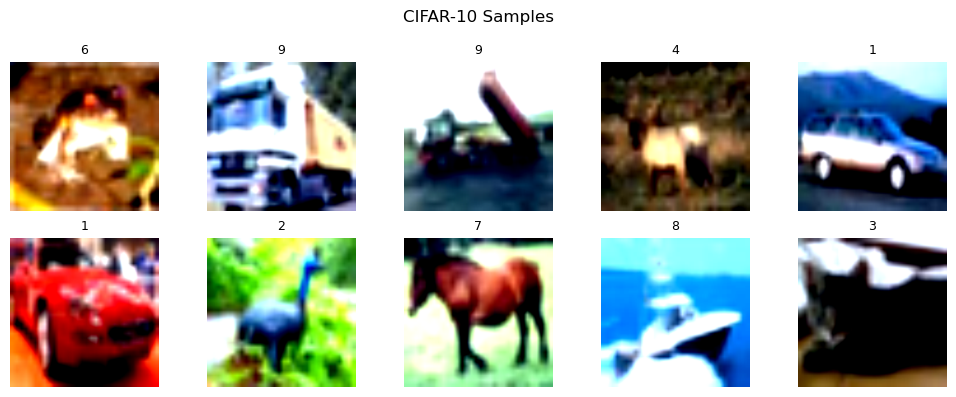

In [ ]:
# code copied from lab 4, just for visualisation

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, label = CIFAR_train_data[i]
    img = img / 2 + 0.5
    ax.imshow(torch.permute(img, (1, 2, 0)))
    ax.set_title(label, fontsize=9)
    ax.axis('off')
plt.suptitle('CIFAR-10 Samples')
plt.tight_layout()
plt.show()

In [ ]:
# Setting up data loaders
def get_data_loaders(batch_size=64, shuffle=True):
    training_dataloader = DataLoader(CIFAR_train_data, batch_size=batch_size, shuffle=shuffle)
    test_dataloader = DataLoader(CIFAR_test_data, batch_size=batch_size, shuffle=False)

    return training_dataloader, test_dataloader

**MobileNetV3**

In [ ]:
# Setting up model

def get_mobile_net_model(in_features=224, out_features=10):

    # in_features is number of in features, need modification to our dataset 
    # out_features is number of out features (i.e., classes), need modifcation to our data

    mobilenet_v3_small = models.mobilenet_v3_small(weights = None)
    mobilenet_v3_small.classifier[3] = nn.Linear(in_features=mobilenet_v3_small.classifier[3].in_features, out_features=out_features)

    print(mobilenet_v3_small.classifier)

    return mobilenet_v3_small

In [ ]:
# Setting up optimiser for model

# TODO: justify the use of AdamW over SGD?
def get_optimiser_for_model(model):
    return torch.optim.AdamW(params=model.parameters(),lr=1e-3, weight_decay=1e-2)

**Training**

In [ ]:
# TBD. Add loss functions in their section or their own.
import loss

logits = ...
targets = ...

class_weights = [3 for i in range(10)] # length = num_classes, just values for testing
samples_per_class = [] # length = num_classes

ce = loss.CrossEntropyLoss()
weighted_ce = loss.WeightedCrossEntropyLoss(class_weights=class_weights)
label_smoothing_ce = loss.LabelSmoothingCrossEntropyLoss(smoothing=0.1)
focal_loss = loss.FocalLoss(gamma=2.0, alpha=class_weights)
class_balanced_loss = loss.ClassBalancedLoss(samples_per_class=samples_per_class, beta=0.9999)

# losses = {
#     "Cross-Entropy": ce(logits, targets),
#     "Weighted Cross-Entropy": weighted_ce(logits, targets),
#     "Label Smoothing CE": label_smoothing_ce(logits, targets),
#     "Focal Loss": focal_loss(logits, targets),
#     "Class-Balanced Loss": class_balanced_loss(logits, targets),
# }

# for name, value in losses.items():
#     print(f"{name}: {value.item():.4f}")

criterion = ce
model = get_mobile_net_model()
optimizer = get_optimiser_for_model(model)
training_loader,testing_loader = get_data_loaders()
steps = 10 # just testing with smaller values for now

training_losses = []
batches_to_train_with = 10

# Main training loop

for i in range(steps):
    model.train()
    training_loss = 0.0
    trained_batches = 0

    for data,labels in training_loader:
        optimizer.zero_grad()
        output = model(data)
        loss_value = criterion(output, labels)
        training_loss += loss_value.item()
        loss_value.backward()
        optimizer.step()

        trained_batches += 1
        if trained_batches > batches_to_train_with:
            break
    
    training_losses.append(training_loss)

print(training_losses)

Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=10, bias=True)
)
[tensor(25.3283, grad_fn=<AddBackward0>), tensor(22.2539, grad_fn=<AddBackward0>), tensor(21.1345, grad_fn=<AddBackward0>), tensor(20.9539, grad_fn=<AddBackward0>), tensor(20.1291, grad_fn=<AddBackward0>), tensor(19.7706, grad_fn=<AddBackward0>), tensor(19.7711, grad_fn=<AddBackward0>), tensor(19.1393, grad_fn=<AddBackward0>), tensor(19.4599, grad_fn=<AddBackward0>), tensor(18.3598, grad_fn=<AddBackward0>)]


**Evaluation**

In [ ]:
eval_loss = 0.0
instances_to_test_with = 200
instances_tested = 0

model.eval()
criterion = ce

with torch.no_grad():
    for data, target in testing_loader:
        prediction = model(data)
        eval_loss += ce(prediction, target).item()
        instances_tested += 1

        if instances_tested > instances_to_test_with:
            break

print(eval_loss)


**Misc.**